## 1) Imports

In [1]:
import numpy as np, pandas as pd, cv2, os, warnings, gc
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.mixed_precision import set_global_policy

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import albumentations as A

2025-11-06 22:05:12.634485: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762466712.911651      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762466712.998123      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 2) Config & Seed

In [2]:
def set_seed(seed=42):
    np.random.seed(seed); tf.random.set_seed(seed); os.environ['PYTHONHASHSEED']=str(seed)
set_seed(42); set_global_policy('mixed_float16')

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    for gpu in physical_devices:
        try: tf.config.experimental.set_memory_growth(gpu, True)
        except Exception: pass
    print(f"GPU Enabled: {len(physical_devices)} device(s)")
else:
    print("No GPU found")
try: tf.config.optimizer.set_jit(True)
except Exception: pass

class CFG:
    data_dir = '/kaggle/input/cassava-leaf-disease-classification'
    train_dir = '/kaggle/input/cassava-leaf-disease-classification/train_images'
    img_size = 320          # 380 nếu GPU đủ mạnh
    num_classes = 5
    batch_size = 12         # giảm nếu OOM, tăng nếu dư VRAM
    # epochs
    stage1_epochs = 3
    stage2_epochs = 10
    stage3_epochs = 5
    # base learning rates
    stage1_lr = 7e-4
    stage2_lr = 5e-4
    stage3_lr = 3e-4
    # split
    val_split = 0.2
    # steps/epoch (có thể chỉnh để trade-off thời gian)
    steps_per_epoch = 600
    val_steps = 160
    # MixUp
    mixup_prob = 0.5
    mixup_alpha = 0.2

class_names = ['CBB','CBSD','CGM','CMD','Healthy']
print("Config ready")

GPU Enabled: 1 device(s)
Config ready


## 3) Data & Transforms (No RandomResizedCrop)

In [3]:
train_df = pd.read_csv(f'{CFG.data_dir}/train.csv')
train_df['image_path'] = train_df['image_id'].apply(lambda x: f"{CFG.train_dir}/{x}")
train_df, valid_df = train_test_split(train_df, test_size=CFG.val_split,
                                      stratify=train_df['label'], random_state=42)
print("Train/Valid:", len(train_df), len(valid_df))

train_transform = A.Compose([
    A.Resize(height=CFG.img_size + 32, width=CFG.img_size + 32),
    A.RandomCrop(height=CFG.img_size, width=CFG.img_size),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=CFG.img_size//12, max_width=CFG.img_size//12, p=0.25),
])
valid_transform = A.Compose([A.Resize(height=CFG.img_size, width=CFG.img_size)])

def apply_albu_then_preprocess(t, img_rgb):
    img = t(image=img_rgb)['image'].astype(np.float32)
    return preprocess_input(img)

Train/Valid: 17117 4280


## 4) Generator with MixUp

In [4]:
def mixup_batch(x, y, alpha=0.2):
    if len(x) < 2: return x, y
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(len(x))
    return lam*x + (1-lam)*x[idx], lam*y + (1-lam)*y[idx]

class SimpleGen(keras.utils.Sequence):
    def __init__(self, df, transform, batch_size, shuffle=True, mixup=False):
        self.df = df.reset_index(drop=True)
        self.t = transform
        self.bs = batch_size
        self.shuffle = shuffle
        self.mixup = mixup
        self.indexes = np.arange(len(self.df))
        self.on_epoch_end()
    def __len__(self): return int(np.ceil(len(self.df)/self.bs))
    def __getitem__(self, idx):
        s,e = idx*self.bs, min((idx+1)*self.bs, len(self.df))
        batch = self.df.iloc[s:e]
        X, y = [], []
        for _, row in batch.iterrows():
            img = cv2.imread(row['image_path'])
            if img is None: img = np.zeros((CFG.img_size, CFG.img_size, 3), dtype=np.uint8)
            else: img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            X.append(apply_albu_then_preprocess(self.t, img))
            y.append(row['label'])
        X = np.array(X, dtype=np.float32); y = keras.utils.to_categorical(y, CFG.num_classes)
        if self.mixup and np.random.rand() < CFG.mixup_prob:
            X, y = mixup_batch(X, y, alpha=CFG.mixup_alpha)
        return X, y
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indexes)

train_gen = SimpleGen(train_df, train_transform, CFG.batch_size, shuffle=True, mixup=True)
valid_gen = SimpleGen(valid_df, valid_transform, CFG.batch_size, shuffle=False, mixup=False)
print("Generators ready")

Generators ready


## 5) Optimizer & Cosine Warmup

In [5]:
class CosineWithWarmup(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr = float(base_lr)
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        total = tf.cast(self.total_steps, tf.float32)
        warmup = tf.cast(self.warmup_steps, tf.float32)

        # warmup: tăng tuyến tính 0 -> base_lr
        warm = tf.minimum(step / tf.maximum(warmup, 1.0), 1.0)

        # cosine sau warmup
        denom = tf.maximum(total - warmup, 1.0)
        progress = tf.clip_by_value((step - warmup) / denom, 0.0, 1.0)
        cosine = 0.5 * (1.0 + tf.cos(np.pi * progress))

        lr = self.base_lr * (warm * cosine + (1.0 - warm) * 0.0)
        return tf.cast(lr, tf.float32)


total_steps = CFG.steps_per_epoch * (CFG.stage1_epochs + CFG.stage2_epochs + CFG.stage3_epochs)
warmup_steps = max(total_steps // 20, 1)
lr_schedule = CosineWithWarmup(CFG.stage1_lr, total_steps, warmup_steps)

## 6) Model (EfficientNet-B4) & Training

In [6]:
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
try:
    from tensorflow.keras.optimizers import AdamW
    USE_ADAMW = True
except Exception:
    from tensorflow.keras import optimizers
    USE_ADAMW = False

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

def build_model(trainable_layers=0):
    base = EfficientNetB4(include_top=False, weights='imagenet',
                          input_shape=(CFG.img_size, CFG.img_size, 3))
    if trainable_layers == 0:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-trainable_layers]:
            layer.trainable = False

    inputs = keras.Input(shape=(CFG.img_size, CFG.img_size, 3))
    x = base(inputs, training=(trainable_layers > 0))
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(CFG.num_classes, activation='softmax', dtype='float32')(x)
    return keras.Model(inputs, outputs)

model = build_model(0)
model.summary()

# ===== Stage 1 =====
lr_schedule_1 = CosineDecayRestarts(
    initial_learning_rate=CFG.stage1_lr,
    first_decay_steps=CFG.steps_per_epoch * max(CFG.stage1_epochs, 1),
    t_mul=1.0, m_mul=1.0, alpha=0.0
)
optimizer_1 = AdamW(learning_rate=lr_schedule_1, weight_decay=1e-4) if USE_ADAMW else optimizers.Adam(learning_rate=lr_schedule_1)
model.compile(optimizer=optimizer_1, loss=loss_fn, metrics=['accuracy'])

cb1 = [EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)]
history1 = model.fit(
    train_gen, validation_data=valid_gen,
    epochs=CFG.stage1_epochs,
    steps_per_epoch=min(CFG.steps_per_epoch, len(train_gen)),
    validation_steps=min(CFG.val_steps, len(valid_gen)),
    callbacks=cb1, verbose=1
)

# ===== Stage 2 (unfreeze top 160 layers) =====
base = model.layers[1]
for layer in base.layers[-160:]:
    layer.trainable = True

lr_schedule_2 = CosineDecayRestarts(
    initial_learning_rate=CFG.stage2_lr,
    first_decay_steps=CFG.steps_per_epoch * max(CFG.stage2_epochs, 1),
    t_mul=1.0, m_mul=1.0, alpha=0.0
)
optimizer_2 = AdamW(learning_rate=lr_schedule_2, weight_decay=1e-4) if USE_ADAMW else optimizers.Adam(learning_rate=lr_schedule_2)
model.compile(optimizer=optimizer_2, loss=loss_fn, metrics=['accuracy'])

cb2 = [
    ModelCheckpoint('best_b4.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
]
history2 = model.fit(
    train_gen, validation_data=valid_gen,
    epochs=CFG.stage2_epochs,
    steps_per_epoch=min(CFG.steps_per_epoch, len(train_gen)),
    validation_steps=min(CFG.val_steps, len(valid_gen)),
    callbacks=cb2, verbose=1
)

# ===== Stage 3 =====
lr_schedule_3 = CosineDecayRestarts(
    initial_learning_rate=CFG.stage3_lr,
    first_decay_steps=CFG.steps_per_epoch * max(CFG.stage3_epochs, 1),
    t_mul=1.0, m_mul=1.0, alpha=0.0
)
optimizer_3 = AdamW(learning_rate=lr_schedule_3, weight_decay=1e-4) if USE_ADAMW else optimizers.Adam(learning_rate=lr_schedule_3)
model.compile(optimizer=optimizer_3, loss=loss_fn, metrics=['accuracy'])

cb3 = [EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1)]
history3 = model.fit(
    train_gen, validation_data=valid_gen,
    epochs=CFG.stage3_epochs,
    steps_per_epoch=min(CFG.steps_per_epoch, len(train_gen)),
    validation_steps=min(CFG.val_steps, len(valid_gen)),
    callbacks=cb3, verbose=1
)

I0000 00:00:1762466731.819105      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 10, 10, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_1 (Cast)                   │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,135,140 (69.18 MB)

 Trainable params: 460,805 (1.76 MB)

 Non-trainable params: 17,674,335 (67.42 MB)

Epoch 1/3


I0000 00:00:1762466753.481650      60 service.cc:148] XLA service 0x7f0300003950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762466753.482364      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762466753.512394      60 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1762466753.602317      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


600/600 ━━━━━━━━━━━━━━━━━━━━ 235s 298ms/step - accuracy: 0.5021 - loss: 1.5188 - val_accuracy: 0.7156 - val_loss: 0.8431
Epoch 2/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 127s 212ms/step - accuracy: 0.6678 - loss: 1.0207 - val_accuracy: 0.7505 - val_loss: 0.8021
Epoch 3/3
600/600 ━━━━━━━━━━━━━━━━━━━━ 53s 89ms/step - accuracy: 0.6776 - loss: 1.0076 - val_accuracy: 0.7495 - val_loss: 0.7901
Restoring model weights from the end of the best epoch: 2.
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6896 - loss: 1.0109
Epoch 1: val_accuracy improved from -inf to 0.72865, saving model to best_b4.h5
600/600 ━━━━━━━━━━━━━━━━━━━━ 182s 125ms/step - accuracy: 0.6897 - loss: 1.0108 - val_accuracy: 0.7286 - val_loss: 0.8244
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7580 - loss: 0.8456
Epoch 2: val_accuracy improved from 0.72865 to 0.83125, saving model to best_b4.h5
600/600 ━━━━━━━━━━━━━━━━━━━━ 101s 169ms/step - accuracy: 0.7580 - loss: 0.8456 - val_accuracy: 0.8313

## 7) Evaluation

Validation Acc: 85.63% | Loss: 0.5891
357/357 ━━━━━━━━━━━━━━━━━━━━ 52s 107ms/step

Classification report:
              precision    recall  f1-score   support

         CBB     0.5887    0.6267    0.6071       217
        CBSD     0.8143    0.7009    0.7534       438
         CGM     0.7528    0.7149    0.7333       477
         CMD     0.9404    0.9647    0.9524      2632
     Healthy     0.6590    0.6628    0.6609       516

    accuracy                         0.8563      4280
   macro avg     0.7510    0.7340    0.7414      4280
weighted avg     0.8548    0.8563    0.8549      4280



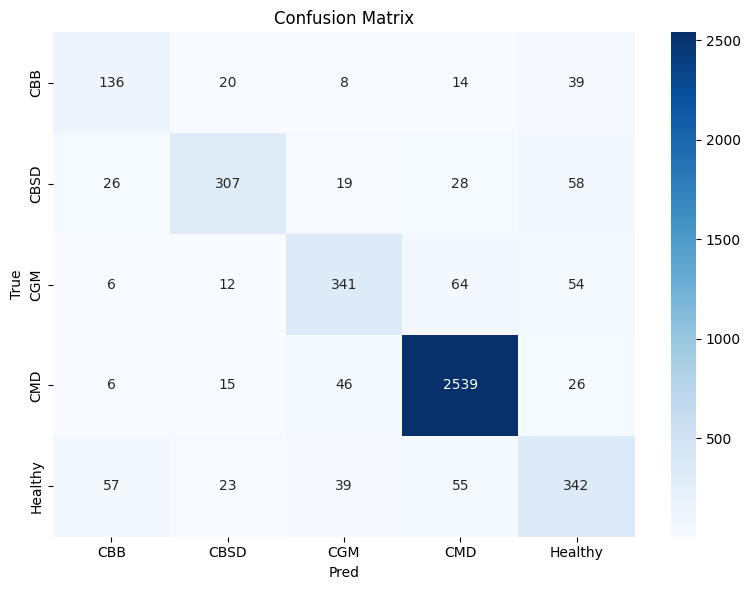

In [7]:
val_loss, val_acc = model.evaluate(valid_gen, verbose=0)
print(f"Validation Acc: {val_acc*100:.2f}% | Loss: {val_loss:.4f}")

y_pred_probs = model.predict(valid_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = valid_df['label'].values

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Pred"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.tight_layout(); plt.show()

## 8) Test Inference — TTA 6-view

In [8]:
test_df = pd.read_csv(f'{CFG.data_dir}/sample_submission.csv')
test_df['image_path'] = test_df['image_id'].apply(lambda x: f'{CFG.data_dir}/test_images/{x}')

def predict_tta6(df, batch_size):
    t_list = [
        A.Compose([A.Resize(CFG.img_size, CFG.img_size)]),
        A.Compose([A.Resize(CFG.img_size+24, CFG.img_size+24), A.CenterCrop(CFG.img_size, CFG.img_size)]),
        A.Compose([A.Resize(CFG.img_size, CFG.img_size), A.HorizontalFlip(p=1.0)]),
        A.Compose([A.Resize(CFG.img_size, CFG.img_size), A.VerticalFlip(p=1.0)]),
        A.Compose([A.Resize(CFG.img_size, CFG.img_size), A.Rotate(limit=10, p=1.0)]),
        A.Compose([A.Resize(CFG.img_size, CFG.img_size), A.RandomBrightnessContrast(0.1,0.1,p=1.0)]),
    ]
    probs = []
    for t in t_list:
        preds_all = []
        for i in range(int(np.ceil(len(df)/batch_size))):
            s,e = i*batch_size, min((i+1)*batch_size, len(df))
            batch = df.iloc[s:e]
            X=[]
            for _, row in batch.iterrows():
                img=cv2.imread(row['image_path'])
                if img is None: img = np.zeros((CFG.img_size, CFG.img_size, 3), dtype=np.uint8)
                else: img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                arr = t(image=img)['image'].astype(np.float32)
                X.append(preprocess_input(arr))
            X = np.array(X, dtype=np.float32)
            preds_all.append(model.predict(X, verbose=0))
        probs.append(np.concatenate(preds_all, axis=0))
    return np.mean(probs, axis=0)

probs = predict_tta6(test_df, CFG.batch_size)
preds = np.argmax(probs, axis=1)

submission = pd.read_csv(f'{CFG.data_dir}/sample_submission.csv')
submission['label'] = preds
submission.to_csv('submission.csv', index=False)
print("Saved submission.csv | head:")
print(submission.head())

Saved submission.csv | head:
         image_id  label
0  2216849948.jpg      2
